<a href="https://colab.research.google.com/github/ota0425/brain-tumor-adversarial-experiment/blob/main/brain_tumor_adversarial_examples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MRI画像に対するAdversarial Examplesの実験

## 1. 実験環境の確認
TensorFlowのバージョンとGPUの利用状況を確認する。

In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. データセットの準備
Google Driveを接続し、Brain Tumor MRI DatasetをColab上に展開する。

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip -oq "/content/drive/MyDrive/ThammasatResearch/dataset/archive.zip" -d "/content/brain_tumor"
print("展開完了")

展開完了


In [ ]:
!find /content/brain_tumor -maxdepth 3 -type d

/content/brain_tumor
/content/brain_tumor/Testing
/content/brain_tumor/Testing/glioma
/content/brain_tumor/Testing/notumor
/content/brain_tumor/Testing/meningioma
/content/brain_tumor/Testing/pituitary
/content/brain_tumor/Training
/content/brain_tumor/Training/glioma
/content/brain_tumor/Training/notumor
/content/brain_tumor/Training/meningioma
/content/brain_tumor/Training/pituitary


## 3. データセットの画像枚数を確認

TrainingとTestingについて、クラスごとの画像枚数を確認する。

In [ ]:
from pathlib import Path

data_dir = Path("/content/brain_tumor")
train_dir = data_dir / "Training"
test_dir = data_dir / "Testing"

image_extensions = {".jpg", ".jpeg", ".png"}

def count_images(directory):
    return sum(
        1 for file in directory.iterdir()
        if file.is_file() and file.suffix.lower() in image_extensions
    )

for split_name, split_dir in [
    ("Training", train_dir),
    ("Testing", test_dir)
]:
    print(f"\n{split_name}")

    for class_dir in sorted(split_dir.iterdir()):
        if class_dir.is_dir():
            print(f"{class_dir.name}: {count_images(class_dir)} images")


Training
glioma: 1400 images
meningioma: 1400 images
notumor: 1400 images
pituitary: 1400 images

Testing
glioma: 400 images
meningioma: 400 images
notumor: 400 images
pituitary: 400 images


## 4. MRI画像の確認

各クラスから2枚ずつ画像を選び、データが正しく読み込まれていることを確認する。

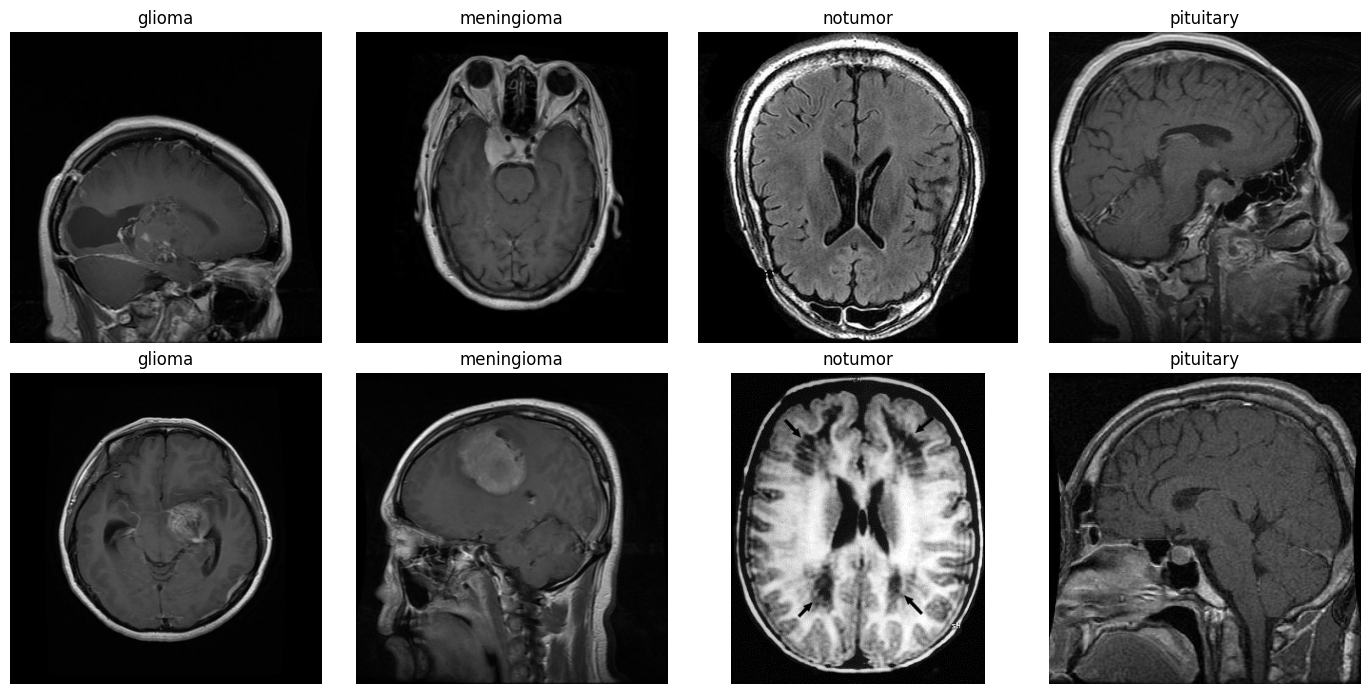

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

random.seed(42)

class_names = sorted([
    directory.name
    for directory in train_dir.iterdir()
    if directory.is_dir()
])

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for column, class_name in enumerate(class_names):
    class_dir = train_dir / class_name

    image_files = [
        file for file in class_dir.iterdir()
        if file.suffix.lower() in image_extensions
    ]

    selected_images = random.sample(image_files, 2)

    for row, image_path in enumerate(selected_images):
        image = Image.open(image_path)

        axes[row, column].imshow(image, cmap="gray")
        axes[row, column].set_title(class_name)
        axes[row, column].axis("off")

plt.tight_layout()
plt.show()

## 5. TensorFlowデータセットの作成

Trainingフォルダの80%を学習用、20%を検証用として使用する。
Testingフォルダは最終評価だけに使用する。
すべての画像を224×224に変換する。

In [ ]:
import tensorflow as tf

image_size = (224, 224)
batch_size = 32
random_seed = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    str(train_dir),
    validation_split=0.2,
    subset="training",
    seed=random_seed,
    image_size=image_size,
    batch_size=batch_size
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    str(train_dir),
    validation_split=0.2,
    subset="validation",
    seed=random_seed,
    image_size=image_size,
    batch_size=batch_size
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    str(test_dir),
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.


In [ ]:
class_names = train_dataset.class_names

print("Classes:", class_names)
print("Number of classes:", len(class_names))

for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Pixel range:", float(tf.reduce_min(images)),
          "to", float(tf.reduce_max(images)))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4
Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: 0.0 to 255.0


## 6. MobileNetV2モデルの作成

ImageNetで事前学習されたMobileNetV2を使用する。
最初はベースモデルの重みを固定し、最後の分類層だけを学習する。

In [ ]:
from tensorflow.keras import layers, models

data_augmentation = models.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
], name="data_augmentation")

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# MobileNetV2の学習済み部分を固定
base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = models.Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 7. ベースラインモデルの学習

MobileNetV2の事前学習済み部分を固定し、MRI画像を分類する出力層を学習する。
検証精度が最も高いモデルをGoogle Driveに保存する。

In [ ]:
import os

# データ読み込みを高速化
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

# モデルの保存先
model_directory = (
    "/content/drive/MyDrive/ThammasatResearch/models"
)

os.makedirs(model_directory, exist_ok=True)

model_path = (
    model_directory + "/baseline_mobilenetv2.keras"
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=model_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
]

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6298 - loss: 0.8962
Epoch 1: val_accuracy improved from None to 0.83125, saving model to /content/drive/MyDrive/ThammasatResearch/models/baseline_mobilenetv2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ThammasatResearch/models/baseline_mobilenetv2.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 18s 96ms/step - accuracy: 0.7440 - loss: 0.6626 - val_accuracy: 0.8313 - val_loss: 0.4391
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8227 - loss: 0.4429
Epoch 2: val_accuracy improved from 0.83125 to 0.85357, saving model to /content/drive/MyDrive/ThammasatResearch/models/baseline_mobilenetv2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/ThammasatResearch/models/baseline_mobilenetv2.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.8348 - loss: 0.4284 - val_accuracy: 0.8536 - val_loss: 0.3862
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8651 - los

## 8. ベースラインモデルのテスト評価

学習時に使用していないTestingデータを用いて、保存したベースラインモデルの性能を評価する。

ここで得られるtest accuracyは、今後FGSMによる敵対的攻撃を行った際の性能低下を比較するための基準値として使用する。

まず、検証精度が最も高かったモデルをGoogle Driveから読み込み、通常のテスト画像に対するlossとaccuracyを測定する。

In [ ]:
import tensorflow as tf
import os

# 保存したベストモデルのパス
model_path = "/content/drive/MyDrive/ThammasatResearch/models/baseline_mobilenetv2.keras"

# モデルが存在するか確認
print("Model exists:", os.path.exists(model_path))

# ベストモデルを読み込み
best_model = tf.keras.models.load_model(model_path)

print("Best model loaded successfully.")

Model exists: True
Best model loaded successfully.


In [ ]:
# 未使用のTestingデータで評価
test_loss, test_accuracy = best_model.evaluate(test_dataset)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.8319 - loss: 0.5203
Test Loss: 0.5203
Test Accuracy: 0.8319
Test Accuracy: 83.19%


### 8.1 評価結果

Testingデータに対する分類性能を測定した。

- Test Loss: 0.5203
- Test Accuracy: 0.8319 (83.19%)

最高Validation Accuracyは91.071%であったのに対し、未使用のTestingデータでは83.19%のAccuracyとなった。

この結果を、FGSMによる敵対的サンプルに対する分類性能を評価する際のベースラインとして使用する。

## 9. 詳細な分類性能の評価

Accuracyだけでなく、各クラスに対する分類性能を確認するため、Testingデータに対してConfusion Matrix、Precision、Recall、F1-scoreを計算する。

これにより、ベースラインモデルがどのクラスを正しく分類できているか、またどのクラス間で誤分類が発生しているかを確認する。

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# クラス名を取得
class_names = test_dataset.class_names

print("Class mapping:")
for i, name in enumerate(class_names):
    print(f"Class {i}: {name}")

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = best_model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    # labelsがone-hotの場合
    if len(labels.shape) > 1:
        true_classes = np.argmax(labels.numpy(), axis=1)
    else:
        true_classes = labels.numpy()

    y_true.extend(true_classes)
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\nNumber of test images:", len(y_true))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

AttributeError: '_PrefetchDataset' object has no attribute 'class_names'